<h1 style="
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    font-size: 36px;
    color: #2c3e50;
    background-color: #ecf0f1;
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    box-shadow: 0px 4px 10px rgba(0, 0, 0, 0.1);">
    NextGen Data Preparation
</h1>

**Authors:** 

<ul style="line-height:1.5;">
<li>Ayman Nassar <a href="mailto:ayman.nassar@usu.edu">(ayman.nassar@usu.edu)</a></li>
<li>David Tarboton <a href="mailto:david.tarboton@usu.edu">(david.tarboton@usu.edu)</a></li>
<li>Furqan Baig <a href="fbaig@illinois.edu">(fbaig@illinois.edu)</a></li>
</ul>

**Last Updated:** 05/15/2026

**Purpose:**

This notebook simplifies the preparation of input data for running NextGen. It helps users subset and retrieve hydrofabric and forcing data, as well as set up model configurations and realizations. For more information on NextGen data preparation, refer to this [**link**](https://pypi.org/project/ngiab-data-preprocess/).

**Audience:**

Researchers and graduate students who are familiar with Jupyter Notebooks, basic Python, and basic hydrologic data analysis.

**Description:**

This notebook accepts inputs such as a gage ID, catchment ID, or Vector Processing Unit (VPU) to define a specific location, along with start and end dates for the time period of interest. It utilizes geometry and model attributes from the [**Hydrofabric Dataset**](https://communityhydrofabric.s3.us-east-1.amazonaws.com/index.html#hydrofabrics/community/). It uses AORC forcing data at a 1-km grid resolution. The forcings are computed as a weighted mean of the gridded AORC data, with weights derived using the `Exact Extract` tool and calculated using `NumPy`.

**Data Description:**

This Jupyter notebook automatically prepares a complete run package for NextGen simulations by extracting geometry and model attributes from [**Hydrofabric Dataset**](https://communityhydrofabric.s3.us-east-1.amazonaws.com/index.html#hydrofabrics/community/), with detailed documentation available [**here**](https://lynker-spatial.s3-us-west-2.amazonaws.com/hydrofabric/v2.2/hfv2.2-data_model.html). It utilizes AORC meteorological forcing data at a 1-km grid resolution and generates all configuration files required for simulation, including the NextGen model configuration (`realization.json`), routing configuration (`troute.yaml`), and model parameter files for each divide (subcatchment).

**Software Requirements:**
This notebook the following library versions:
 >  matplotlib: 3.8.3  
    pandas: 2.2.1  

It also uses code from `hydrofabric_visualization_utils.py` and `forcings_visualization_utilis.py`.

<div style="
    padding: 15px 20px; 
    background-color: #e2f0fe; 
    border-left: 6px solid #3b82f6; 
    color: #1e3a8a; 
    border-radius: 4px; 
    margin-bottom: 20px;
    font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
">
    <h3 style="margin-top: 0; color: #1e3a8a; font-weight: 700; display: flex; align-items: center; gap: 8px;">
        💡 Quick Note Before You Begin
    </h3>
    <p style="margin-bottom: 10px; font-size: 1.05em;">
        To make sure everything runs smoothly and all settings initialize correctly, <strong>please take a moment to restart the kernel before running the cells below.</strong>
    </p>
    <p style="margin: 0; font-size: 0.95em;">
        <strong>How to do this:</strong> Simply navigate to the <strong>Kernel</strong> menu at the top and select <span style="background-color: rgba(0,0,0,0.05); padding: 2px 6px; border-radius: 3px; border: 1px solid rgba(0,0,0,0.1);"><strong>“Restart Kernel and Clear Outputs of All Cells”</strong></span>. Thank you!
    </p>
</div>

<div style="background:#13294b; border-left:6px solid #5cd6ff; padding:12px 16px; border-radius:8px; margin-top:0px; margin-bottom:0px;">
  <h3 style="margin:0; font-size:20px; font-weight:700; color:#eaf7ff;">
    1. Prepare the Python Environment
  </h3>
</div>

In this section, we import all the **necessary Python libraries and modules** used throughout this workflow.  
This notebook relies on two specialized visualization modules designed for working with **NextGen HydroFabric** and **Forcing datasets**.

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 14px; border-radius: 8px; font-family: 'Segoe UI', sans-serif; font-size: 15px; color: #000000; margin-top: 10px;">
  <strong>Key Modules Used:</strong>
  <ul style="margin-top: 8px; margin-bottom: 0;">
    <li><strong><code>hydrofabric_visualization_utils</code></strong> — Provides tools for visualizing HydroFabric datasets.
    <li><strong><code>forcings_utils</code></strong> — Provides functions to aggregate AORC forcing variables 
      (e.g., precipitation, temperature, wind) from the **divide scale** to the **watershed scale**, 
      enabling spatiotemporal analysis and visualization.</li>
  </ul>
</div>

In [9]:
# ----------------------------- Importing Required Libraries -----------------------------

import json
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from hydrofabric_visualization_utils import conus_hydrofabric_download, display_hydrofabric_map
from forcings_utils import (
    process_time_series,
    get_var_label,
    get_var_full_name,
    get_var_units,
    list_supported_variables,
    compute_mean_annual,   # main function that calculates the annual mean values
    join_to_gpkg,          # merges result statistics to polygon divides GPKG
    save_csv_and_gpkg,     # writes CSV + merged GPKG output files
    plot_mean_annual_map,  # makes the map visualization
    make_mean_annual_map  
)

<div style="background:#13294b; border-left:6px solid #5cd6ff; padding:12px 16px; border-radius:8px; margin-top:0; margin-bottom:0;">
  <h3 style="margin:0; font-size:20px; font-weight:700; color:#eaf7ff;">
    2. Set Inputs
  </h3>
</div>

<p style="margin-top:0; padding-top:4px;">
This section allows you to define the <strong>key input variables</strong> required for <strong>NextGen data preprocessing</strong>.  
These parameters specify the <strong>spatial domain of interest</strong> and the <strong>temporal range</strong> for data extraction and processing.
</p>

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 14px; border-radius: 8px; font-family: 'Segoe UI', sans-serif; font-size: 15px; color: #000000; margin-top: 10px;">
  <strong>Inputs Defined in the Next Cell:</strong>
  <ul style="margin-top: 8px; margin-bottom: 0;">
    <li><strong>Hydrofabric ID:</strong> Specifies the spatial domain of interest. This can represent:
      <ul>
        <li>A <em>catchment ID</em> (e.g., <code>cat-7080</code>)</li>
        <li>A <em>gage ID</em> (e.g., <code>gage-10154200</code>)</li>
        <li>A <em>Vector Processing Unit (VPU)</em> code (e.g., <code>01</code>)</li>
      </ul>
    </li>
    <li><strong>Start Date:</strong> Defines the beginning of the simulation or data extraction period (format: <code>YYYY-MM-DD</code>).</li>
    <li><strong>End Date:</strong> Defines the ending date of the simulation or data extraction period (format: <code>YYYY-MM-DD</code>).</li>
  </ul>
</div>


In [10]:
# Define your Hydrofabric ID
hydrofabric_id = "gage-03574500"  # This can be a catchment ID (e.g., 'cat-7080'), a gage ID (e.g., 'gage-10154200'), 
hydrofabric_id =(
    "gage-02464000"
    "gage-02361000"
    "gage-02469800"
    "gage-03574500"
)                           # or a Vector Processing Unit (VPU) code (e.g., '01')
# Start date
start_date = "2020-01-01"    # Specify the start date in the format 'YYYY-MM-DD'

# End date
end_date = "2022-12-31"      # Specify the end date in the format 'YYYY-MM-DD'
home_dir = Path.home()


<div style="background:#13294b; border-left:6px solid #5cd6ff; padding:12px 16px; border-radius:8px; margin-top:0; margin-bottom:0;">
  <h3 style="margin:0; font-size:20px; font-weight:700; color:#eaf7ff;">
    3. Subset Hydrofabric using Catchment ID, Gage ID, or VPU
  </h3>
</div>

<p style="margin-top:0; padding-top:0;">
This section delineates the entire upstream area of your point of interest (e.g., catchment, gage, flowpath, etc.) and outputs the result as a GeoPackage. More information on the different hydrofabric IDs that can be used to define the spatial domain of interest is available in this 
<a href="https://pypi.org/project/ngiab-data-preprocess/"><strong>link</strong></a>. 
It uses geometry and model attributes from the 
<a href="https://communityhydrofabric.s3.us-east-1.amazonaws.com/index.html#hydrofabrics/community/"><strong>Hydrofabric Dataset</strong></a>, 
and additional details on all data sources can be found 
<a href="https://lynker-spatial.s3-us-west-2.amazonaws.com/hydrofabric/v2.2/hfv2.2-data_model.html"><strong>here</strong></a>.
</p>


<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Fira Code', monospace; font-size: 14px; color: #000000; margin-top: 12px;">
  <strong>Command:</strong>
  <pre style="margin-top: 10px; background-color:#1e1e1e; color:#ffffff; padding:10px; border-radius:6px;"><code>!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i $hydrofabric_id -s</code></pre>
</div>

#### Command Breakdown

<table style="border-collapse: collapse; width: 100%; font-size: 14px;">
  <thead>
    <tr style="background-color: navy; color: white;">
      <th style="padding: 8px; text-align: left;">Argument</th>
      <th style="padding: 8px; text-align: left;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>!source /ngen/.venv/bin/activate</code></td>
      <td style="padding: 8px; text-align: left;">Activates the Python virtual environment where all required <code>NextGen</code> and <code>ngiab_data_cli</code> dependencies are installed.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>python -m ngiab_data_cli</code></td>
      <td style="padding: 8px; text-align: left;">Executes the <code>ngiab_data_cli</code> module, which handles data preprocessing and forcing generation for the HydroFabric subset.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>-i "$hydrofabric_id"</code></td>
      <td style="padding: 8px; text-align: left;">Specifies the unique HydroFabric subset ID (e.g., a gage or catchment identifier) for which data will be generated.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>-f</code></td>
      <td style="padding: 8px; text-align: left;">Forces overwriting of existing output files in the subset directory if they already exist.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>--start "$start_date"</code></td>
      <td style="padding: 8px; text-align: left;">Defines the start date for the forcing dataset (e.g., <code>2020-01-01</code>).</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>--end "$end_date"</code></td>
      <td style="padding: 8px; text-align: left;">Defines the end date for the forcing dataset (e.g., <code>2020-12-31</code>).</td>
    </tr>
  </tbody>
</table>

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Segoe UI', sans-serif; font-size: 14px; color: #000000; margin-top: 12px;">
  💡 <strong>Tip:</strong> For more details on additional arguments and usage options for the <code>ngiab_data_cli</code> hydrofabric subset command, please visit the official documentation:<br>
  <a href="https://pypi.org/project/ngiab-data-preprocess/" target="_blank">https://pypi.org/project/ngiab-data-preprocess/</a>
</div>

In [11]:
### CONUS HydroFabric download
# Downloads the national (CONUS) hydrofabric dataset if it is not already on this machine (`~/.ngiab`).  
# **First run only** — may take **2–3 minutes**; later runs skip download if data is present.

conus_hydrofabric_download()

In [12]:
# Subsetting the HydroFabric Dataset
# This step subsets the HydroFabric dataset using the `hydrofabric_id` variable defined in the previous cell.

!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i $hydrofabric_id -s

⠏ loadingng
2026-07-28 00:58:37,150 - INFO - Getting catid for 03574500, in /home/mhchowdhury/.ngiab/hydrofabric/v2.2/conus_nextgen.gpkg
2026-07-28 00:58:37,151 - INFO - Found cat-1011929 from gage-03574500
2026-07-28 00:58:37,151 - INFO - Processing cat-1011929 in /home/mhchowdhury/ngiab_preprocess_output/gage-03574500
2026-07-28 00:58:37,521 - INFO - Upstream catchments: 108
2026-07-28 00:58:37,521 - INFO - Subsetting hydrofabric
2026-07-28 00:58:37,579 - INFO - Subsetting tables: ['divides', 'divide-attributes', 'flowpath-attributes', 'flowpath-attributes-ml', 'flowpaths', 'hydrolocations', 'nexus', 'pois', 'lakes', 'network']
2026-07-28 00:58:38,362 - INFO - Subset complete for 261 features (catchments + nexuses)
2026-07-28 00:58:38,362 - INFO - Subsetting complete.
2026-07-28 00:58:38,362 - INFO - All operations completed successfully.
2026-07-28 00:58:38,362 - INFO - Output folder: file:////home/mhchowdhury/ngiab_preprocess_output/gage-03574500


<div style="border-left: 6px solid #3b82f6; background:#f0f7ff; padding:12px 14px; border-radius:8px;">
  💡 <strong>Tip:</strong> For this Jupyter notebook example, the Hydrofabric subset is saved at:<br>
  <code>/home/jovyan/ngiab_preprocess_output/{hydrofabric_id}/config</code><br><br>
  For instance, in this example:<br>
  <code>/home/jovyan/ngiab_preprocess_output/gage-10109001/config</code>
</div>

Visualize the hydrofabric subset on an interactive map, showcasing key features such as divides (polygons), flowpaths (lines), and nexus (points), and gages (points-pin mark) .

### 🗺️ Visualizing the HydroFabric Subset

In this step, you will **visualize the HydroFabric subset** on an interactive map to explore the key hydrologic features extracted during the subsetting process.  
The visualization provides spatial context and allows you to verify the accuracy of the subset.

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 14px; border-radius: 8px; font-family: 'Segoe UI', sans-serif; font-size: 15px; color: #000000; margin-top: 12px;">
  <strong>Goal:</strong> Display the main HydroFabric components on an interactive map:
  <ul style="margin-top: 8px; margin-bottom: 0;">
    <li><strong>Divides:</strong> Polygon boundaries (black outlines) representing watershed or catchment areas.</li>
    <li><strong>Flowpaths:</strong> Blue line features representing flow directions or stream reaches.</li>
    <li><strong>Nexus:</strong> Red circular markers representing hydrologic connection nodes.</li>
    <li><strong>Gages:</strong> Point features (shown as pin markers) representing monitoring stations.</li>
  </ul>
</div>

In [13]:
# Provide the path to your GeoPackage
gpkg_path = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/config/{hydrofabric_id}_subset.gpkg"

# Display the interactive map
display_hydrofabric_map(gpkg_path)

<div style="background:#13294b; border-left:6px solid #5cd6ff; padding:10px 16px; border-radius:8px; margin-top:0; margin-bottom:-6px;">
  <h3 style="margin:0; font-size:20px; font-weight:700; color:#eaf7ff;">
    4. Generate Forcings for a Specific Catchment ID
  </h3>
</div>

<p style="margin-top:0; margin-bottom:0; padding-top:0;">
Subset and retrieve forcing data, which are then aggregated for each individual divide (subcatchment) across the entire spatial domain. This process uses pre-defined start and end dates for the specified time period of interest.
</p>


<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Fira Code', monospace; font-size: 14px; color: #000000; margin-top: 12px;">
  <strong>Command:
  <pre style="margin-top: 10px; background-color:#1e1e1e; color:#ffffff; padding:10px; border-radius:6px; overflow-x:auto;"><code>!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i "$hydrofabric_id" -f --start "$start_date" --end "$end_date"</code></pre>
</div>

#### Command Breakdown

<table style="border-collapse: collapse; width: 100%; font-size: 14px;">
  <thead>
    <tr style="background-color: navy; color: white;">
      <th style="padding: 8px; text-align: left;">Argument</th>
      <th style="padding: 8px; text-align: left;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>!source /ngen/.venv/bin/activate</code></td>
      <td style="padding: 8px; text-align: left;">Activates the Python virtual environment where all required <code>NextGen</code> and <code>ngiab_data_cli</code> dependencies are installed.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>python -m ngiab_data_cli</code></td>
      <td style="padding: 8px; text-align: left;">Executes the <code>ngiab_data_cli</code> module, which handles data preprocessing and forcing generation for the HydroFabric subset.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>-i "$hydrofabric_id"</code></td>
      <td style="padding: 8px; text-align: left;">Specifies the unique HydroFabric subset ID (e.g., a gage or catchment identifier) for which data will be generated.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>-f</code></td>
      <td style="padding: 8px; text-align: left;">Forces overwriting of existing output files in the subset directory if they already exist.</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>--start "$start_date"</code></td>
      <td style="padding: 8px; text-align: left;">Defines the start date for the forcing dataset (e.g., <code>2020-01-01</code>).</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code>--end "$end_date"</code></td>
      <td style="padding: 8px; text-align: left;">Defines the end date for the forcing dataset (e.g., <code>2020-12-31</code>).</td>
    </tr>
  </tbody>
</table>

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Segoe UI', sans-serif; font-size: 14px; color: #000000; margin-top: 12px;">
  💡 <strong>Tip:</strong> For more details on additional arguments and usage options for the <code>ngiab_data_cli</code> forcing subset command, please visit the official documentation:<br>
  <a href="https://pypi.org/project/ngiab-data-preprocess/" target="_blank">https://pypi.org/project/ngiab-data-preprocess/</a>
</div>

In [14]:
# Subsetting the Forcings Dataset
# Use the variables defined earlier (`hydrofabric_id`, `start_date`, `end_date`) to 
# subset and preprocess the AORC forcings for your HydroFabric subset.

!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i "$hydrofabric_id" -f --start "$start_date" --end "$end_date"

⠏ loadingng
2026-07-28 00:59:18,598 - INFO - Getting catid for 03574500, in /home/mhchowdhury/.ngiab/hydrofabric/v2.2/conus_nextgen.gpkg
2026-07-28 00:59:18,599 - INFO - Found cat-1011929 from gage-03574500
2026-07-28 00:59:18,599 - INFO - Processing cat-1011929 in /home/mhchowdhury/ngiab_preprocess_output/gage-03574500
2026-07-28 00:59:18,971 - INFO - Upstream catchments: 108
2026-07-28 00:59:18,971 - INFO - Generating forcings from 2020-01-01 00:00:00 to 2022-12-31 00:00:00...
2026-07-28 00:59:30,744 - INFO - No cache found
2026-07-28 00:59:30,753 - INFO - Selected time range and clipped to bounds
2026-07-28 00:59:32,758 - INFO - For more detailed progress, see the Dask dashboard http://localhost:8787/status
2026-07-28 01:09:25,937 - INFO - Successfully saved data to: /home/mhchowdhury/ngiab_preprocess_output/gage-03574500/forcings/raw_gridded_data.nc
2026-07-28 01:09:28,287 - INFO - Computing zonal stats in parallel for all timesteps
2026-07-28 01:09:29,613 - INFO - Total steps: 8, 

<h3 style="text-align: center; font-size: 20px; font-family: 'Segoe UI', sans-serif; margin-bottom: 10px; color: #003366;">
  🌧️ <strong>AORC Forcing Inputs</strong>
</h3>

<table style="border-collapse: collapse; width: 100%; font-family: 'Segoe UI', sans-serif; font-size: 14px; border: 1px solid #d0d7de;">
  <thead>
    <tr style="background-color: #003366; color: white;">
      <th style="padding: 10px; text-align: left;">Variable Name</th>
      <th style="padding: 10px; text-align: left;">Description</th>
      <th style="padding: 10px; text-align: left;">Units</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f8faff;">
      <td style="padding: 8px; text-align: left;"><code><strong>APCP_surface</strong></code></td>
      <td style="padding: 8px; text-align: left;">Precipitation at the surface level</td>
      <td style="padding: 8px; text-align: left;">Meters (m)</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code><strong>DLWRF_surface</strong></code></td>
      <td style="padding: 8px; text-align: left;">Downward Longwave Radiation Flux at the surface</td>
      <td style="padding: 8px; text-align: left;">Watts per square meter (W/m²)</td>
    </tr>
    <tr style="background-color: #f8faff;">
      <td style="padding: 8px; text-align: left;"><code><strong>PRES_surface</strong></code></td>
      <td style="padding: 8px; text-align: left;">Air Pressure at the surface</td>
      <td style="padding: 8px; text-align: left;">Pascals (Pa)</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code><strong>SPFH_2maboveground</strong></code></td>
      <td style="padding: 8px; text-align: left;">Specific Humidity at 2 meters Above Ground Level</td>
      <td style="padding: 8px; text-align: left;">Kilograms per kilogram (kg/kg)</td>
    </tr>
    <tr style="background-color: #f8faff;">
      <td style="padding: 8px; text-align: left;"><code><strong>precip_rate</strong></code></td>
      <td style="padding: 8px; text-align: left;">Precipitation rate at the surface</td>
      <td style="padding: 8px; text-align: left;">Meters per second (m/s)</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code><strong>DSWRF_surface</strong></code></td>
      <td style="padding: 8px; text-align: left;">Downward Shortwave Radiation Flux at the surface</td>
      <td style="padding: 8px; text-align: left;">Watts per square meter (W/m²)</td>
    </tr>
    <tr style="background-color: #f8faff;">
      <td style="padding: 8px; text-align: left;"><code><strong>TMP_2maboveground</strong></code></td>
      <td style="padding: 8px; text-align: left;">Temperature at 2 meters Above Ground Level</td>
      <td style="padding: 8px; text-align: left;">Kelvin (K)</td>
    </tr>
    <tr>
      <td style="padding: 8px; text-align: left;"><code><strong>UGRD_10maboveground</strong></code></td>
      <td style="padding: 8px; text-align: left;">Eastward (U) Wind component at 10 meters Above Ground Level</td>
      <td style="padding: 8px; text-align: left;">Meters per second (m/s)</td>
    </tr>
    <tr style="background-color: #f8faff;">
      <td style="padding: 8px; text-align: left;"><code><strong>VGRD_10maboveground</strong></code></td>
      <td style="padding: 8px; text-align: left;">Northward (V) Wind component at 10 meters Above Ground Level</td>
      <td style="padding: 8px; text-align: left;">Meters per second (m/s)</td>
    </tr>
  </tbody>
</table>


<h3 style="background-color:#003366; color:white; padding:10px 14px; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:18px;">
📈 Visualizing Forcing Time-Series
</h3>

<p style="font-family:'Segoe UI',sans-serif; font-size:15px; color:#000000; margin-top:8px;">
Visualize time-series plots for different forcing variables to better understand their <strong>trends</strong>, <strong>patterns</strong>, and <strong>relationships</strong> over time.  
These plots provide insight into the temporal behavior of key meteorological drivers such as precipitation, temperature, radiation, and wind.
</p>


<h4 style="background-color:#e6ebff; color:#000000; padding:8px 12px; border-left: 5px solid #6c63ff; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:16px; margin-top:16px;">
🔹 Selecting the Forcing Variable and Input Paths
</h4>
<p style="font-family:'Segoe UI',sans-serif; font-size:15px; color:#000000; margin-top:6px;">
Specify the <strong>forcing variable</strong> to analyze (as listed in the AORC table above),  
and define the file paths for the <strong>Forcings NetCDF dataset</strong> <code>forcings_path</code> and the corresponding  
<strong>HydroFabric GeoPackage</strong> <code>gpkg_path</code> for your selected <code>hydrofabric_id</code>.  
These inputs will be used to extract and visualize the variable’s time-series data.
</p>

In [15]:
# Specify the variable name from the table above
var_name = "precip_rate"  # Choose the variable to analyze

# Define the path of forcings
forcings_path = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/forcings/forcings.nc"

# Define the path of hydrofabric geopackage dataset
gpkg_path = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/config/{hydrofabric_id}_subset.gpkg"

<h4 style="background-color:#e6ebff; color:#000000; padding:8px 12px; border-left: 5px solid #6c63ff; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:16px; margin-top:16px;">
🔹 Hourly Time-Series Plot for the Selected Forcing Variable
</h4>

Saved plot to: /home/mhchowdhury/hourly_precip_rate.png


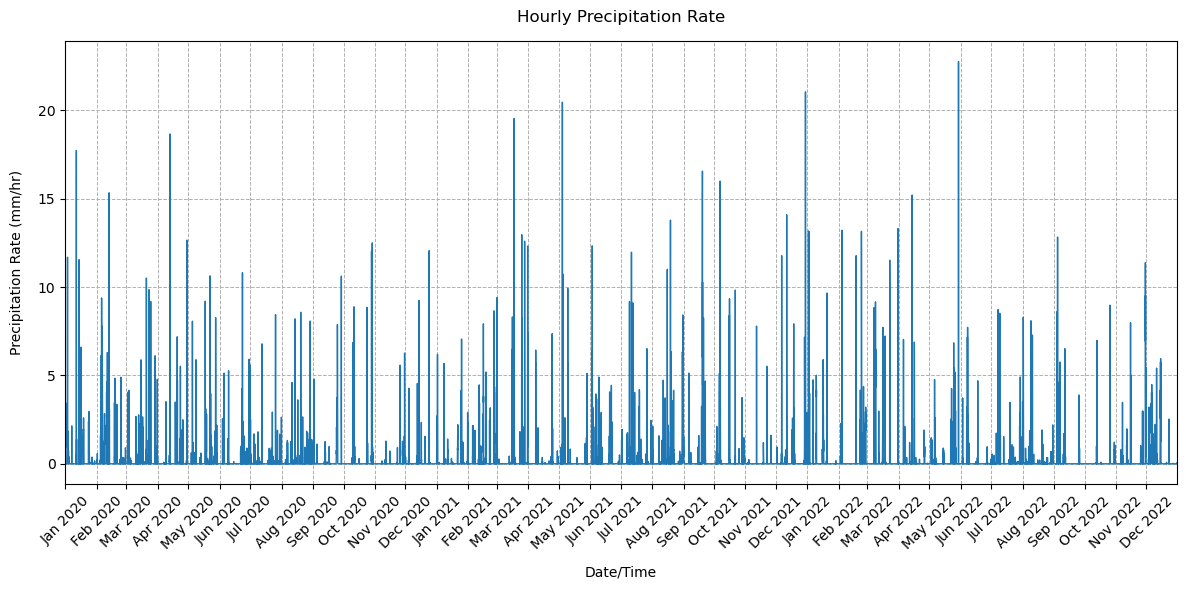

In [17]:
# Build basin-mean time series for the selected variable
series = process_time_series(
    forcings_path,
    gpkg_path,
    var_name,
)

# Determine optimal month tick interval
start = series.index.min()
end   = series.index.max()

# Total number of months represented in the series
months_span = (end.year - start.year) * 12 + (end.month - start.month) + 1

# Target number of tick labels on the x-axis
target_ticks = 24
interval = max(1, months_span // target_ticks)

# Plot
fig = plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, linewidth=1, label=get_var_full_name(var_name))

plt.xlabel("Date/Time", labelpad=10)
plt.ylabel(get_var_label(var_name) or "Value", labelpad=10)
plt.title(f"Hourly {get_var_full_name(var_name)}", pad=14)

ax = plt.gca()
ax.set_xlim(start, end)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", linewidth=0.7)
plt.tight_layout()

# ---- Save PNG ----
output_path = f"{home_dir}/hourly_{var_name}.png"
plt.savefig(output_path, dpi=200)
print("Saved plot to:", output_path)

plt.show()


<h4 style="background-color:#e6ebff; color:#000000; padding:8px 12px; border-left: 5px solid #6c63ff; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:16px; margin-top:16px;">
🔹 Cumulative Plot for the Selected Forcing Variable
</h4>

Saved cumulative plot to: /home/mhchowdhury/cumulative_precip_rate.png


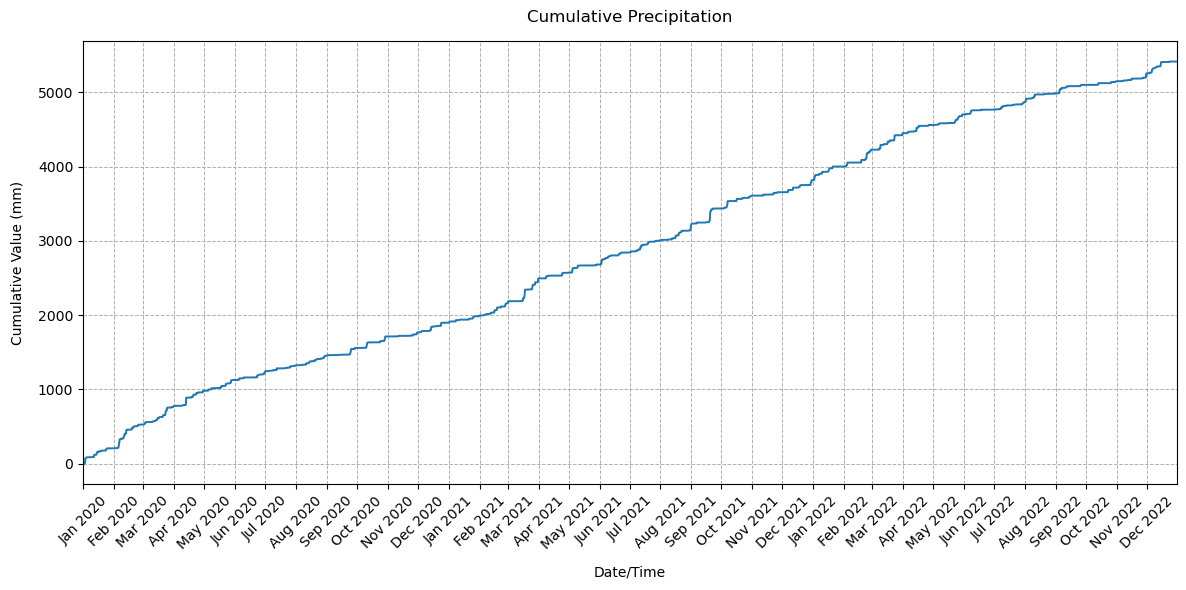

In [18]:
# --- Build cumulative series ---
series = process_time_series(
    forcings_path,
    gpkg_path,
    var_name,
)
cum_series = series.cumsum()

# Auto compute spacing for clean ticks
start = cum_series.index.min()
end   = cum_series.index.max()

months_span = (end.year - start.year) * 12 + (end.month - start.month) + 1
target_ticks = 24
interval = max(1, months_span // target_ticks)

fig = plt.figure(figsize=(12,6))
plt.plot(cum_series.index, cum_series.values, linewidth=1.4, label=get_var_full_name(var_name) + " (Cumulative)")

# ----- precipitation special title + axis label -----
if var_name.lower() in ["precip_rate", "apcp_surface", "apcp_surface", "precipitation", "precip"]:
    plt.title("Cumulative Precipitation", pad=14)
    plt.ylabel("Cumulative Value (mm)", labelpad=10)
else:
    plt.title(f"Cumulative {get_var_full_name(var_name)}", pad=14)
    plt.ylabel(get_var_label(var_name) or "Value", labelpad=10)

plt.xlabel("Date/Time", labelpad=10)

ax = plt.gca()
ax.set_xlim(start, end)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", linewidth=0.7)
plt.tight_layout()

# ---- Save PNG ----
output_path = f"{home_dir}/cumulative_{var_name}.png"
plt.savefig(output_path, dpi=200)
print("Saved cumulative plot to:", output_path)

plt.show()


<h4 style="background-color:#e6ebff; color:#000000; padding:8px 12px; border-left: 5px solid #6c63ff; border-radius:6px; font-family:'Segoe UI',sans-serif; font-size:16px; margin-top:16px;">
🔹 Compute Mean Annual Basin-Averaged Values and Generate Spatial Map Visualization
</h4>

<div style="background-color:#f3f6ff; border-left:4px solid #6c63ff; padding:6px 10px; border-radius:6px; font-size:14px; margin-top:4px; margin-bottom:8px;">
<strong>Spatially Averaged Forcing Map</strong><br>
Forcing source path:<br>
<code>/home/jovyan/ngiab_preprocess_output/{hydrofabric_id}/forcings/forcings.nc</code>
</div>


Detected Kind: rate | Units: mm s^-1 | Rate base: per_second
Saved PNG map to: /home/mhchowdhury/mean_annual_precip_rate.png


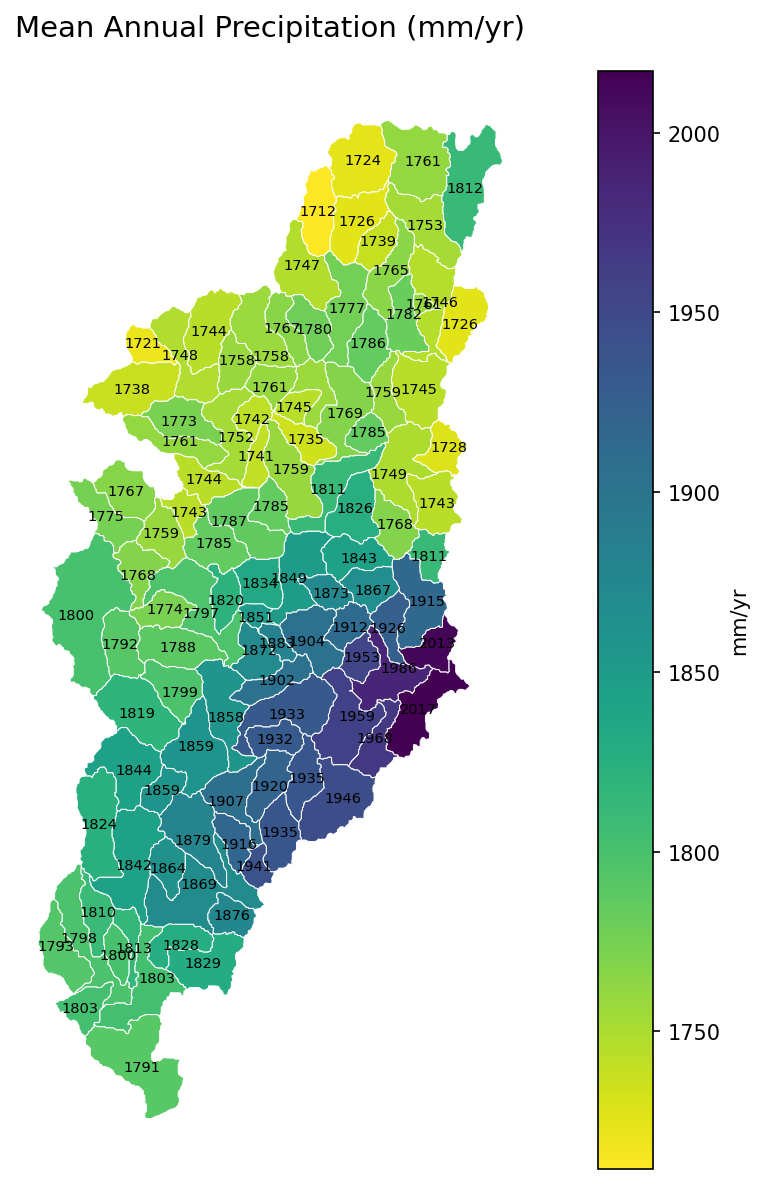

In [19]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import xarray as xr

# --- Open the NetCDF dataset ---
ds = xr.open_dataset(forcings_path)

# Normalize catchment dimension name if needed
if "catchment-id" in ds.dims and "catchment" not in ds.dims:
    ds = ds.rename({"catchment-id": "catchment"})

# --- Compute Annual Statistics ---
# compute_mean_annual detects "rate" vs "state" automatically (override with force_kind="rate"/"state" if needed)
stats_df, meta = compute_mean_annual(ds, var_name, force_kind=None)
print("Detected Kind:", meta.get("kind"), "| Units:", meta.get("units"), "| Rate base:", meta.get("rate_base"))

# --- Basic checks ---
if stats_df is None or stats_df.empty:
    raise ValueError("compute_mean_annual returned an empty stats_df — nothing to plot.")

# --- Join stats to HydroFabric polygons ---
gdf_map = join_to_gpkg(gpkg_path, stats_df)
if gdf_map is None or gdf_map.empty:
    raise ValueError("join_to_gpkg produced an empty GeoDataFrame — check gpkg_path and join keys.")

if "mean_annual" not in gdf_map.columns:
    raise ValueError("Column 'mean_annual' not found in gdf_map. Columns available: "
                     + ", ".join(map(str, gdf_map.columns)))

if gdf_map.geometry.is_empty.all():
    raise ValueError("All geometries are empty — verify HydroFabric polygons in the GPKG.")

# --- Plot with GeoPandas and annotate values ---
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Choropleth
gdf_map.plot(
    column="mean_annual",
    ax=ax,
    cmap="viridis_r",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

# ---- Add units to legend bar ----
cb_ax = fig.axes[-1]   # colorbar axis
cb_ax.set_ylabel("mm/yr", fontsize=10)

# Annotate polygon interiors with the mean_annual values (integer labels, no decimals)
for _, row in gdf_map.iterrows():
    geom = row.geometry
    if geom is not None and not geom.is_empty:
        pt = row.geometry.representative_point()  # safer than centroid
        val = row.get("mean_annual", np.nan)
        if np.isfinite(val):
            ax.text(
                pt.x, pt.y, f"{int(round(val))}",
                ha="center", va="center",
                fontsize=7, color="black", zorder=10
            )
            
# Title & layout
units = meta.get("units", "")
ax.set_title("Mean Annual Precipitation (mm/yr)", fontsize=14)
ax.set_axis_off()
fig.tight_layout()

# --- Save PNG ---
output_path = f"{home_dir}/mean_annual_{var_name}.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")
print("Saved PNG map to:", output_path)

# Show inline
plt.show()


<div style="background-color:#f3f6ff; border-left:4px solid #6c63ff; padding:6px 10px; border-radius:6px; font-size:14px; margin-top:4px; margin-bottom:8px;">
<strong>Spatially Averaged Forcing Map (Raw Gridded)</strong><br>
Calculated spatial average using the raw gridded forcing dataset combined with HydroFabric catchment geometries.<br>
<code>/home/jovyan/ngiab_preprocess_output/gage-10109001/forcings/raw_gridded_data.nc</code>
</div>


Saved PNG map to: /home/mhchowdhury/mean_annual_raw_gridded_precip_rate.png


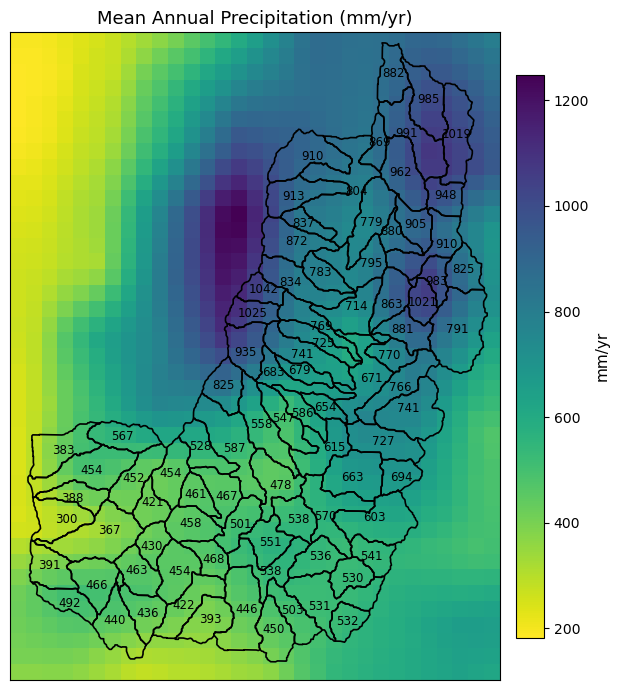

In [20]:
# --- Inputs ---
hydrofabric_id = "gage-10109001"  # change here to reuse the cell for another basin

# Paths
nc_path   = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/forcings/raw_gridded_data.nc"
gpkg_path = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/config/{hydrofabric_id}_subset.gpkg"

# Target variable in the raw-gridded forcing (e.g., "precip_rate", "DLWRF_surface", etc.)
var = "precip_rate"

# --- Mean-annual map over the HydroFabric catchment(s) ---
fig, gdf_out, raster_da = make_mean_annual_map(nc_path, gpkg_path, var)

# ---- Save PNG ----
output_path = f"{home_dir}/mean_annual_raw_gridded_{var}.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")
print("Saved PNG map to:", output_path)

# Display the figure in the notebook
fig


<div style="background:#13294b; border-left:6px solid #5cd6ff; padding:10px 16px; border-radius:8px; margin-top:0; margin-bottom:-6px;">
  <h3 style="margin:0; font-size:20px; font-weight:700; color:#eaf7ff;">
    5. Create Model Configuration/Realization
  </h3>
</div>

<p style="margin-top:0; margin-bottom:0; padding-top:0;">
Generates all necessary configuration files to run NextGen, including <strong>realization.json</strong> for model setup, <strong>troute.yaml</strong> for routing, and model configurations for each divide (subcatchment) within the spatial domain of interest.
</p>

<div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Fira Code', monospace; font-size: 14px; color: #000000; margin-top: 12px;">
  <strong>Command:
  <pre style="margin-top: 10px; background-color:#1e1e1e; color:#ffffff; padding:10px; border-radius:6px; overflow-x:auto;"><code>!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i "$hydrofabric_id" -r --start "$start_date" --end "$end_date"</code></pre>
</div>

<table style="border-collapse: collapse; width: 100%; font-size: 14px;"> <thead> <tr style="background-color: navy; color: white;"> <th style="padding: 8px; text-align: left;">Argument</th> <th style="padding: 8px; text-align: left;">Description</th> </tr> </thead> <tbody> <tr> <td style="padding: 8px; text-align: left;"><code>!source /ngen/.venv/bin/activate</code></td> <td style="padding: 8px; text-align: left;">Activates the Python virtual environment used by the <code>NextGen</code> modeling framework. This ensures that the correct dependencies (e.g., <code>xarray</code>, <code>ngiab_data_cli</code>, and <code>hydrofabric</code> libraries) are available for execution.</td> </tr> <tr> <td style="padding: 8px; text-align: left;"><code>python -m ngiab_data_cli</code></td> <td style="padding: 8px; text-align: left;">Runs the <code>ngiab_data_cli</code> module as a script. This command-line interface (CLI) performs data preprocessing for NextGen HydroFabric subsets — including downloading, formatting, and generating meteorological forcing files.</td> </tr> <tr> <td style="padding: 8px; text-align: left;"><code>-i "$hydrofabric_id"</code></td> <td style="padding: 8px; text-align: left;">Specifies the unique HydroFabric subset ID (e.g., a gage or catchment identifier). This tells the script which region or watershed subset to prepare forcing data for.</td> </tr> <tr> <td style="padding: 8px; text-align: left;"><code>-r</code></td> <td style="padding: 8px; text-align: left;">Creates a realization for the given feature.</td> </tr> <tr> <td style="padding: 8px; text-align: left;"><code>--start "$start_date"</code></td> <td style="padding: 8px; text-align: left;">Defines the start date for the forcing dataset (e.g., <code>--start "2020-01-01"</code>). The CLI will begin processing data from this date.</td> </tr> <tr> <td style="padding: 8px; text-align: left;"><code>--end "$end_date"</code></td> <td style="padding: 8px; text-align: left;">Defines the end date for the forcing dataset (e.g., <code>--end "2020-12-31"</code>). The CLI will process all data up to this date.</td> </tr> </tbody> </table> <div style="background-color:#f3f6ff; border-left: 5px solid #6c63ff; padding: 12px; border-radius: 6px; font-family: 'Segoe UI', sans-serif; font-size: 14px; color: #000000; margin-top: 12px;"> 💡 <strong>Tip:</strong><br> 1) For more details and official documentation, visit: <a href="https://pypi.org/project/ngiab-data-preprocess/" target="_blank">https://pypi.org/project/ngiab-data-preprocess/</a><br><br> 2) The output from the <code>-r</code> (realization) command will be stored under:<br> <code>/home/jovyan/ngiab_preprocess_output/{hydrofabric_id}/config</code><br> For example, in this case the full path is:<br> <code>/home/jovyan/ngiab_preprocess_output/gage-10109001/config</code> </div>

In [21]:
# Set-up Model Configurations / Realization
# Use the variables defined earlier (`hydrofabric_id`, `start_date`, `end_date`) to
# generate the model configuration and realization files needed to run the model

!source /ngen/.venv/bin/activate && python -m ngiab_data_cli -i "$hydrofabric_id" -r --start "$start_date" --end "$end_date"

⠏ loadingng
2026-07-28 01:12:24,089 - INFO - Getting catid for 10109001, in /home/mhchowdhury/.ngiab/hydrofabric/v2.2/conus_nextgen.gpkg
2026-07-28 01:12:24,090 - INFO - Found cat-2861391 from gage-10109001
2026-07-28 01:12:24,090 - INFO - Processing cat-2861391 in /home/mhchowdhury/ngiab_preprocess_output/gage-10109001
2026-07-28 01:12:24,542 - INFO - Upstream catchments: 88
2026-07-28 01:12:24,542 - INFO - Creating realization from 2020-01-01 00:00:00 to 2022-12-31 00:00:00...
2026-07-28 01:12:24,794 - INFO - downloaded calibrated parameters for gage-10109001
2026-07-28 01:12:24,935 - INFO - Realization creation complete.
2026-07-28 01:12:24,935 - INFO - All operations completed successfully.
2026-07-28 01:12:24,935 - INFO - Output folder: file:////home/mhchowdhury/ngiab_preprocess_output/gage-10109001


<h4 style="background-color:#e8ecff; color:#111; padding:12px 16px; border-left:6px solid #4338ca; border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:17px; margin-top:20px;">
🔹 Specify the Model Outputs
</h4>

The `realization.json` file is the main configuration file that controls how a NextGen model is set up and executed. It includes a `global` section containing one or more formulations, such as `bmi_multi`, which define the model type, forcing settings, time configuration, routing options, and output structure. Within the `bmi_multi` formulation, the `output_variables` field specifies which model variables will be written to the output files. These variables can represent fluxes, storages, state variables, or other diagnostic outputs—such as `Q_OUT`, `EVAPOTRANS`, `GW_STORAGE`, and `SNEQV`. The specific variables available depend on the hydrologic model components included in the NextGen configuration.

In [22]:
# Define the realization.josn path
realization_path = f"{home_dir}/ngiab_preprocess_output/{hydrofabric_id}/config/realization.json"

# Defines the list of model output variables (runoff, ET, snow states, etc.).
output_vars = [
    "RAIN_RATE", "GIUH_RUNOFF", "DIRECT_RUNOFF", "NASH_LATERAL_RUNOFF",
    "DEEP_GW_TO_CHANNEL_FLUX", "SOIL_TO_GW_FLUX", "Q_OUT", "POTENTIAL_ET",
    "ACTUAL_ET", "GW_STORAGE", "SOIL_STORAGE", "SOIL_STORAGE_CHANGE",
    "SURF_RUNOFF_SCHEME", "NWM_PONDED_DEPTH", "QINSUR", "SNEQV", "SNOWH",
    "QSNOW", "ACSNOM", "ECAN", "ETRAN", "QSEVA", "EVAPOTRANS", "QRAIN",
    "CMC", "SNLIQ", "FSNO"
]

# Load JSON
with open(realization_path, "r") as f:
    realization = json.load(f)

for form in realization.get("global", {}).get("formulations", []):
    if form.get("name") == "bmi_multi":
        params = form.get("params", {})
        if "modules" in params:
            new_params = {}
            for k, v in params.items():
                if k == "modules":
                    new_params["output_variables"] = output_vars
                new_params[k] = v
            form["params"] = new_params
        else:
            params["output_variables"] = output_vars

# Save JSON
with open(realization_path, "w") as f:
    json.dump(realization, f, indent=4)

print("Inserted 'output_variables' before 'modules' in:", realization_path)

Inserted 'output_variables' before 'modules' in: /home/mhchowdhury/ngiab_preprocess_output/gage-10109001/config/realization.json
